# 📊 Paso 1 — Análisis Exploratorio de Datos (EDA)
**Dataset:** Consumo eléctrico industrial
**Objetivo:** Predecir el tipo de carga (`Load_Type`): Light_Load, Medium_Load, Maximum_Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('outputs/figures', exist_ok=True)
sns.set_theme(style='whitegrid')
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


## 1. Cargar el dataset

In [2]:
ARCHIVO = r'd:\ExperimentoIAIA\data\raw\Steel_industry_data.csv' 
COLUMNA_OBJETIVO = 'Load_Type'

try:
    df = pd.read_csv(ARCHIVO)
    print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
    print(df.head())
except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo en {ARCHIVO}")

df = pd.read_csv(ARCHIVO)
print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
df.head()

Dataset cargado: 35040 filas, 11 columnas
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         10

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## 2. Información general del dataset

In [3]:
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print('\n=== ESTADÍSTICAS GENERALES ===')
df.describe()

=== TIPOS DE DATOS ===
date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

=== ESTADÍSTICAS GENERALES ===


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


## 3. Valores nulos

In [4]:
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen = resumen[resumen['Nulos'] > 0]

if resumen.empty:
    print('✅ No hay valores nulos en el dataset')
else:
    print('⚠️ Columnas con valores nulos:')
    print(resumen)

✅ No hay valores nulos en el dataset


## 4. Distribución de la variable objetivo (Load_Type)

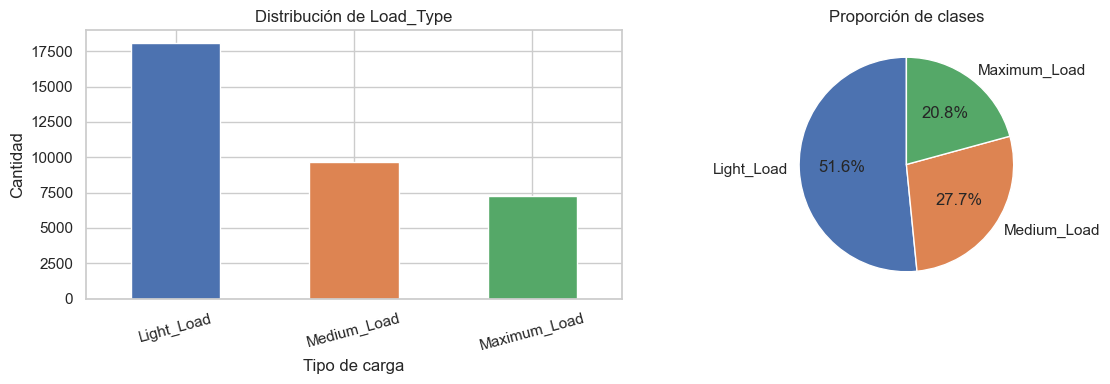

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

conteo = df['Load_Type'].value_counts()
colores = ['#4C72B0', '#DD8452', '#55A868']

conteo.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white')
axes[0].set_title('Distribución de Load_Type')
axes[0].set_xlabel('Tipo de carga')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=colores, startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig('outputs/figures/distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()
print(conteo)

## 5. Distribución de variables numéricas

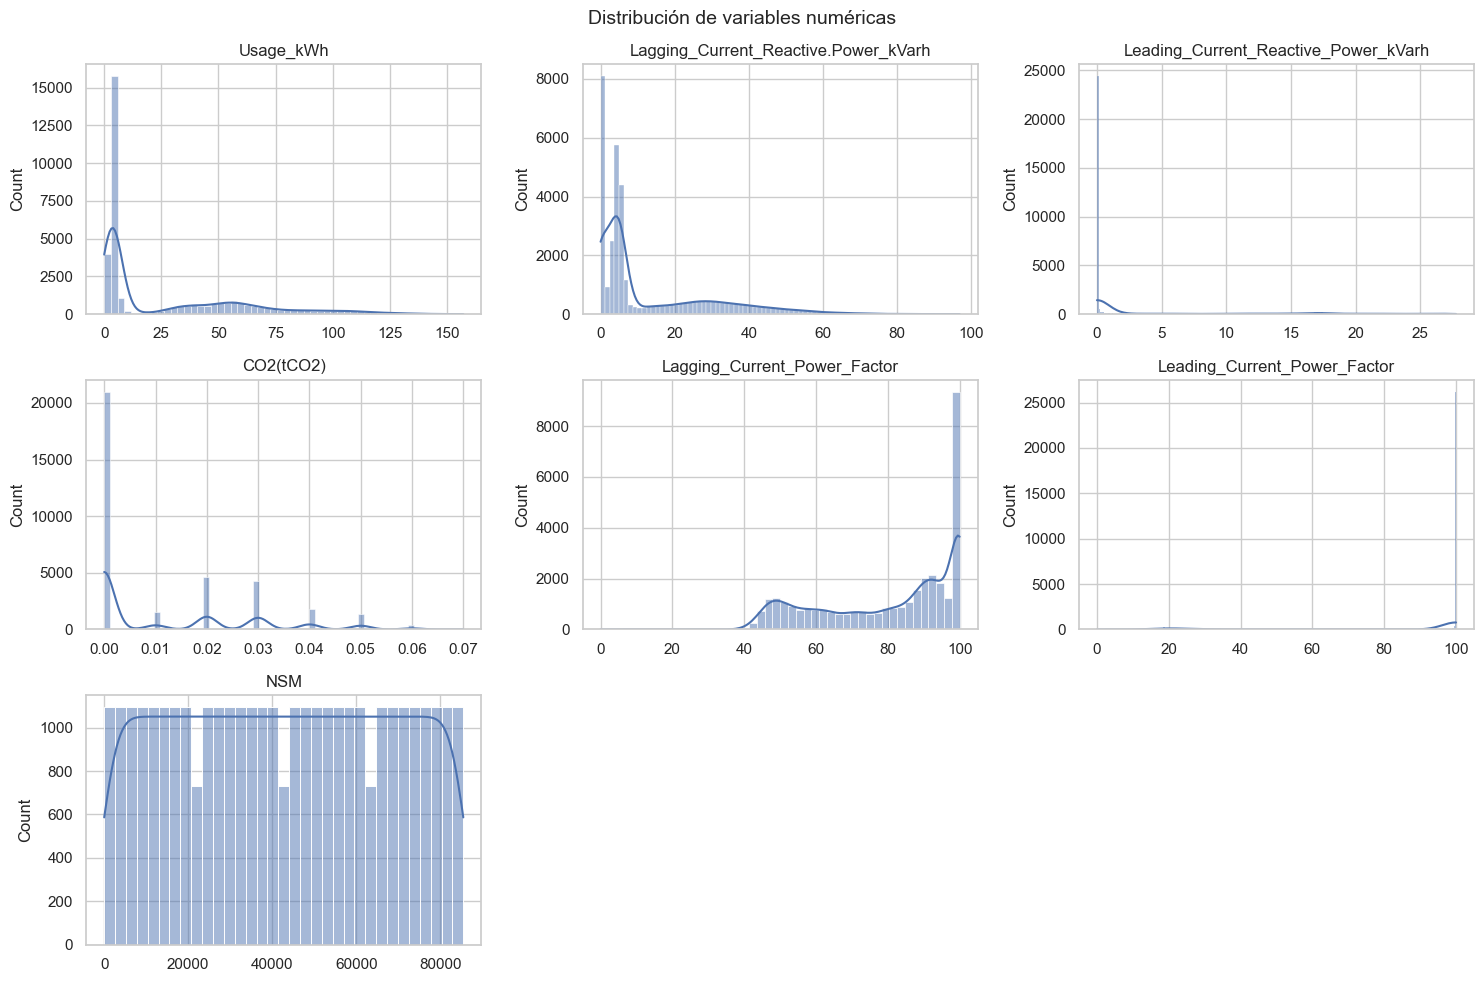

In [6]:
cols_numericas = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
                  'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
                  'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/figures/distribucion_variables.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribución de variables categóricas

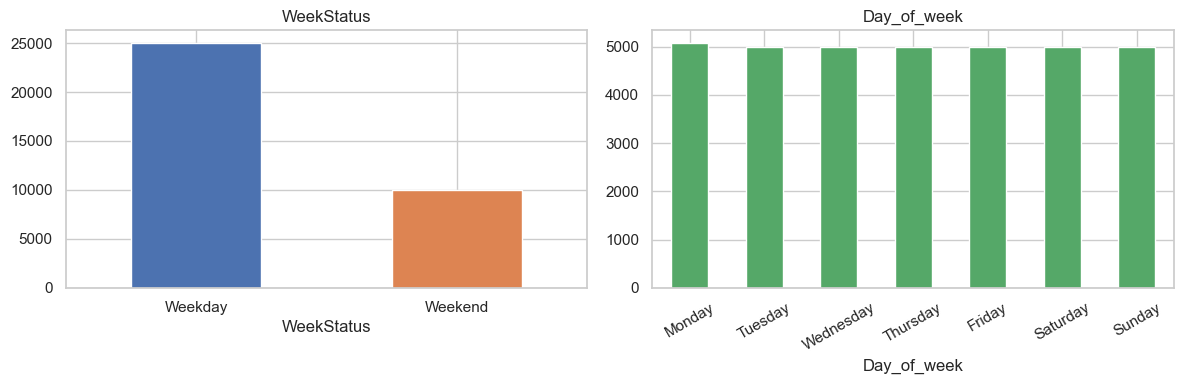

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['WeekStatus'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('WeekStatus')
axes[0].tick_params(axis='x', rotation=0)

df['Day_of_week'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868', edgecolor='white')
axes[1].set_title('Day_of_week')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('outputs/figures/distribucion_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Mapa de correlaciones (variables numéricas)

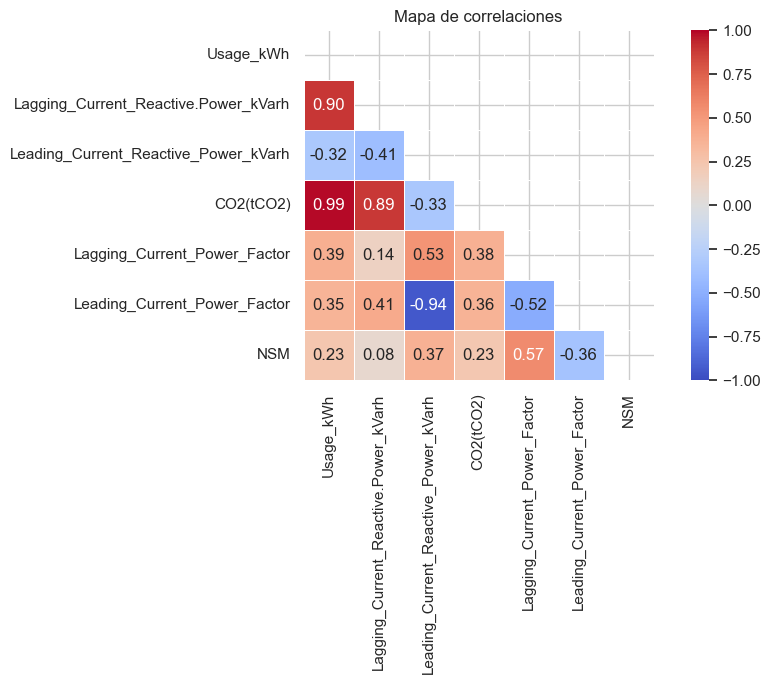

In [8]:
plt.figure(figsize=(10, 7))
correlacion = df[cols_numericas].corr()
mascara = np.triu(np.ones_like(correlacion, dtype=bool))
sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mascara, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Mapa de correlaciones')
plt.tight_layout()
plt.savefig('outputs/figures/correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Boxplots por tipo de carga

C:\Users\ACER\AppData\Local\Temp\ipykernel_18748\56576225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Load_Type', y=col, data=df, ax=axes[i], palette=paleta)
C:\Users\ACER\AppData\Local\Temp\ipykernel_18748\56576225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Load_Type', y=col, data=df, ax=axes[i], palette=paleta)
C:\Users\ACER\AppData\Local\Temp\ipykernel_18748\56576225.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Load_Type', y=col, data=df, ax=axes[i], palette=paleta)
C:\Users\ACER\AppData\Local\Temp\ipykern

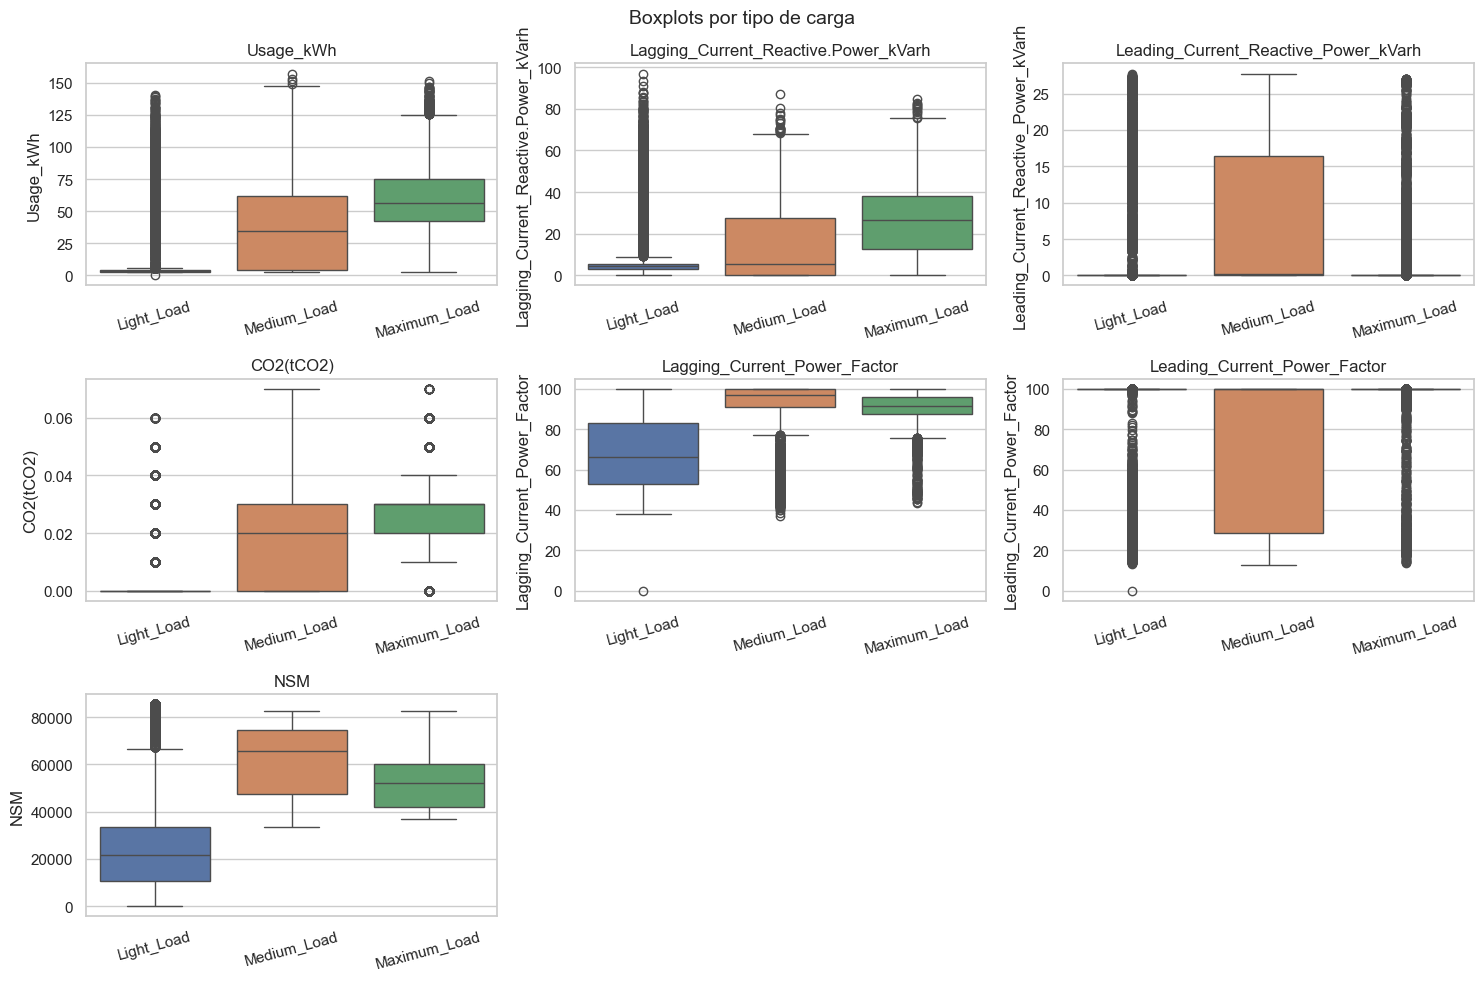

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
paleta = {'Light_Load': '#4C72B0', 'Medium_Load': '#DD8452', 'Maximum_Load': '#55A868'}

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='Load_Type', y=col, data=df, ax=axes[i], palette=paleta)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots por tipo de carga', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/figures/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ Resumen del EDA

In [11]:
print('=' * 50)
print('RESUMEN DEL DATASET')
print('=' * 50)
print(f'Filas:               {df.shape[0]}')
print(f'Columnas:            {df.shape[1]}')
print(f'Variables numéricas: {len(cols_numericas)}')
print(f'Variables categóricas: WeekStatus, Day_of_week')
print(f'Columna a predecir:  Load_Type')
print(f'Valores nulos:       {df.isnull().sum().sum()}')
print(f'Filas duplicadas:    {df.duplicated().sum()}')
print(f'\nClases:')
print(df['Load_Type'].value_counts())
print('=' * 50)
print('✅ EDA completado. Continúa con 02_preprocessing.ipynb')

RESUMEN DEL DATASET
Filas:               35040
Columnas:            11
Variables numéricas: 7
Variables categóricas: WeekStatus, Day_of_week
Columna a predecir:  Load_Type
Valores nulos:       0
Filas duplicadas:    0

Clases:
Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64
✅ EDA completado. Continúa con 02_preprocessing.ipynb
